In [1]:
# Imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt


In [79]:
# Array of r values
R = 0.01
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 0.7

# Defining constants
U = 1
H = 1
k = np.ones(N)
v_parallel = 1

# Equilibrium pressure and potential
L_p = 2
L_phi = 2
phi_0 = np.exp(-r_values/L_p)
p_0  = np.exp(-r_values/L_phi)

# Which mode
m = 1

In [80]:
r_values

array([0.7002, 0.7004, 0.7006, 0.7008, 0.701 , 0.7012, 0.7014, 0.7016,
       0.7018, 0.702 , 0.7022, 0.7024, 0.7026, 0.7028, 0.703 , 0.7032,
       0.7034, 0.7036, 0.7038, 0.704 , 0.7042, 0.7044, 0.7046, 0.7048,
       0.705 , 0.7052, 0.7054, 0.7056, 0.7058, 0.706 , 0.7062, 0.7064,
       0.7066, 0.7068, 0.707 , 0.7072, 0.7074, 0.7076, 0.7078, 0.708 ,
       0.7082, 0.7084, 0.7086, 0.7088, 0.709 , 0.7092, 0.7094, 0.7096,
       0.7098, 0.71  ])

# Matrix Helper Functions

In [81]:
def create_first_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(1, N-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i-1] = -1

    matrix[0][0] = -3 
    matrix[0][1] = 4
    matrix[0][2] = -1

    matrix[N-1][N-3] = 1 
    matrix[N-1][N-2] = -4
    matrix[N-1][N-1] = 3

    return matrix / (2 * dx)

def create_second_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(1, N-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i] = -2
        matrix[i][i-1] = 1

    matrix[0][0] = 2
    matrix[0][1] = -5
    matrix[0][2] = 4
    matrix[0][3] = -1

    matrix[N-1][N-4] = -1
    matrix[N-1][N-3] = 4
    matrix[N-1][N-2] = -5
    matrix[N-1][N-1] = 2

    return matrix / (dx ** 2)

def create_third_derivative_matrix(N, dx):
    matrix = np.zeros((N,N))

    for i in range(2, N-2, 1):
        matrix[i][i-2] = -1
        matrix[i][i-1] = 2
        matrix[i][i+1] = -2
        matrix[i][i+2] = 1

    matrix[0][0] = -5
    matrix[0][1] = 18
    matrix[0][2] = -24
    matrix[0][3] = 14
    matrix[0][4] = -3

    matrix[N-1][N-1] = 5
    matrix[N-1][N-2] = -18
    matrix[N-1][N-3] = 24
    matrix[N-1][N-4] = -14
    matrix[N-1][N-5] = 3

    matrix[1][0] = -3
    matrix[1][1] = 10
    matrix[1][2] = -12
    matrix[1][3] = 6
    matrix[1][4] = -1

    matrix[N-2][N-1] = 3
    matrix[N-2][N-2] = -10
    matrix[N-2][N-3] = 12
    matrix[N-2][N-4] = -6
    matrix[N-2][N-5] = 1

    return (matrix / (2 * (dx ** 3)))

def create_m_laplacian(N, dx, m, r_values):
    D1 = create_first_derivative_matrix(N, dx)
    D2 = create_second_derivative_matrix(N, dx)

    return (
        D2
        + np.diag(1 / r_values) @ D1
        - np.diag(m**2 / (r_values**2))
    )

# Dirichlet boundary conditions at edge
# NOTE: may want to impose boundary conditions for phi[0] later on....
# This is for eigenvalue problem gamma Ax = Bx, phi(r = R) = 0
def enforce_bc(A, B, N, dx):
    A[N-1][:] = 0
    B[N-1][:] = 0
    B[N-1][N-1] = 1

    B[0][:] = 0
    B[0][0] = 1
    A[0][:] = 0

    B[N][:] = 0
    B[N][N] = 1
    A[N][:] = 0

    # D1 = create_first_derivative_matrix(N, dx)
    # B[0][:] = np.concatenate([D1[0][:], np.zeros(N)])
    # A[0][:] = 0

    return A, B

## Linear Stability Operator

The eigenvalue problem to be solved is:

$$
\gamma
\begin{pmatrix} \Delta_m & 0 \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}
=
\begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} \\ \mathcal{L}_{21} & \mathcal{L}_{22} \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}.
$$

### Linear operators (expanded form)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
    - \frac{imU}{r}\left(P_0''\frac{\partial}{\partial r} + P_0'\,\frac{\partial^2}{\partial r^2}\right)
    + \frac{im^3 U}{r^3}\,P_0'
    + H
    - \nu_\parallel \Delta_m,
$$

$$
\mathcal{L}_{12}
  = \frac{imU}{r}\left(\varphi_0''' + \varphi_0''\,\frac{\partial}{\partial r}\right) - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = -\nu_\parallel^P - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

### Linear operators (for benchmarking purposes we drop sources, parallel/perpendicular loss, FLR effects, line tying effects)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
$$

$$
\mathcal{L}_{12}
  = - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

In [82]:
# Initalizing matrices
D1 = create_first_derivative_matrix(N, dr)
D2 = create_second_derivative_matrix(N, dr)
D3 = create_third_derivative_matrix(N, dr)
Dm = create_m_laplacian(N, dr, m, r_values)

diag_r = np.diag(r_values)
diag_div_r = np.diag(1 / r_values)

omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

# Defining opereators
L11 = (-1j * m * omega_0_diag @ Dm 
       + 1j * m * diag_div_r @ D_phi_prime_diag)

L12 = - 2j * m * np.diag(k)
L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
L22 = - (1j * m * omega_0_diag)

In [83]:
# Reduce eigenvalue problem to gamma * Ax = Bx

A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
])

B = np.block([
    [L11, L12],
    [L21, L22]
])

A, B = enforce_bc(A, B, N, dr)

In [84]:
eigenvalues, eigenvectors = eig(B, A)

# Each column of eigenvectors is an eigenvector
x0 = eigenvectors[:, 0]  # eigenvector for eigenvalues[0]

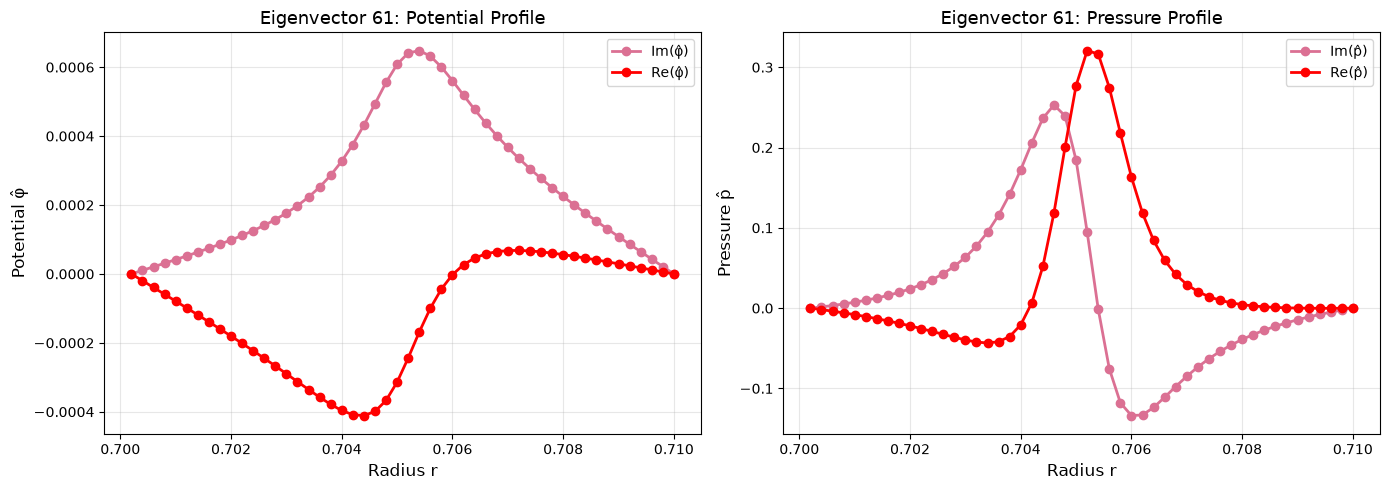

In [85]:
# Eigenvalue for null space vectors are inf, so we only look at the finite eigenvalues
finite_mask = np.isfinite(eigenvalues)
finite_evals = eigenvalues[finite_mask]
finite_indices = np.where(finite_mask)[0]
eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]
# eigenvector_index = 15

eigenvector = eigenvectors[:, eigenvector_index]
potential = eigenvector[:N]
pressure = eigenvector[N:2*N]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot potential
ax1.plot(r_values, np.imag(potential), 'o-', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential), 'o-',linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12)
ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title(f'Eigenvector {eigenvector_index}: Potential Profile', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot pressure
ax2.plot(r_values, np.imag(pressure), 'o-', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure), 'o-',linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12)
ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title(f'Eigenvector {eigenvector_index}: Pressure Profile', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

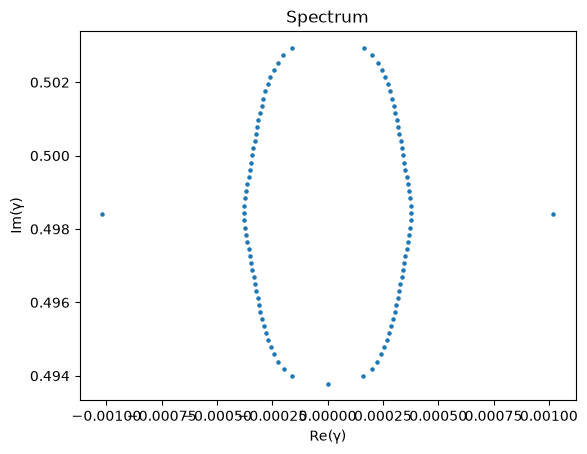

In [86]:
plt.scatter(np.real(finite_evals), np.imag(finite_evals), s=5)
plt.xlabel("Re(γ)"); plt.ylabel("Im(γ)")
plt.title("Spectrum")
plt.show()

In [38]:
np.max(np.real(finite_evals))

np.float64(0.0020414586655371357)

# Testing m scaling

In [ ]:
import numpy as np
from scipy.linalg import eig

m_values = np.arange(1,101,1)
gamma_values = 

R = 0.002
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 0.099

k = np.ones(N)

# Equilibrium pressure and potential
L_p = 2
L_phi = 2
phi_0 = np.exp(-r_values/L_p)
p_0  = np.exp(-r_values/L_phi)

print(r_values)

for i in range(100):
    m = m_values[i]

    print(m)

    # Initalizing matrices
    D1 = create_first_derivative_matrix(N, dr)
    D2 = create_second_derivative_matrix(N, dr)
    D3 = create_third_derivative_matrix(N, dr)
    Dm = create_m_laplacian(N, dr, m, r_values)

    diag_r = np.diag(r_values)
    diag_div_r = np.diag(1 / r_values)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

    # Defining opereators
    L11 = (-1j * m * omega_0_diag @ Dm 
        + 1j * m * diag_div_r @ D_phi_prime_diag)

    L12 = - 2j * m * np.diag(k)
    L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
    L22 = - (1j * m * omega_0_diag)

    A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N, dr)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

[0.09904 0.09908 0.09912 0.09916 0.0992  0.09924 0.09928 0.09932 0.09936
 0.0994  0.09944 0.09948 0.09952 0.09956 0.0996  0.09964 0.09968 0.09972
 0.09976 0.0998  0.09984 0.09988 0.09992 0.09996 0.1     0.10004 0.10008
 0.10012 0.10016 0.1002  0.10024 0.10028 0.10032 0.10036 0.1004  0.10044
 0.10048 0.10052 0.10056 0.1006  0.10064 0.10068 0.10072 0.10076 0.1008
 0.10084 0.10088 0.10092 0.10096 0.101  ]
1
2
3
4
5
6
7
8
9
10


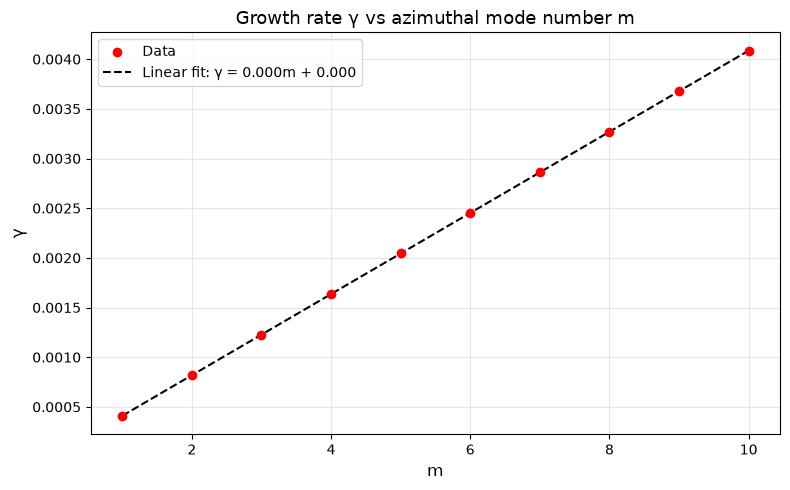

In [8]:
import numpy as np
import matplotlib.pyplot as plt

coeffs = np.polyfit(m_values, gamma_values, 1)
fit_line = np.polyval(coeffs, m_values)

plt.figure(figsize=(8, 5))
plt.scatter(m_values, gamma_values, color='red', zorder=5, label='Data')
plt.plot(m_values, fit_line, color='black', linestyle='--', label=f'Linear fit: γ = {coeffs[0]:.3f}m + {coeffs[1]:.3f}')
plt.xlabel('m', fontsize=12)
plt.ylabel('γ', fontsize=12)
plt.title('Growth rate γ vs azimuthal mode number m', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Testing k scaling

In [10]:
import numpy as np
from scipy.linalg import eig

k_values = np.arange(1,11,1)
gamma_values = [0,0,0,0,0,0,0,0,0,0]

R = 0.002
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 0.099
m = 1

ones = np.ones(N)

# Equilibrium pressure and potential
L_p = 2
L_phi = 2
phi_0 = np.exp(-r_values/L_p)
p_0  = np.exp(-r_values/L_phi)

print(r_values)

for i in range(10):
    k = k_values[i]
    print(k)

    k = k * ones

    # Initalizing matrices
    D1 = create_first_derivative_matrix(N, dr)
    D2 = create_second_derivative_matrix(N, dr)
    D3 = create_third_derivative_matrix(N, dr)
    Dm = create_m_laplacian(N, dr, m, r_values)

    diag_r = np.diag(r_values)
    diag_div_r = np.diag(1 / r_values)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

    # Defining opereators
    L11 = (-1j * m * omega_0_diag @ Dm 
        + 1j * m * diag_div_r @ D_phi_prime_diag)

    L12 = - 2j * m * np.diag(k)
    L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
    L22 = - (1j * m * omega_0_diag)

    A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N, dr)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

[0.09904 0.09908 0.09912 0.09916 0.0992  0.09924 0.09928 0.09932 0.09936
 0.0994  0.09944 0.09948 0.09952 0.09956 0.0996  0.09964 0.09968 0.09972
 0.09976 0.0998  0.09984 0.09988 0.09992 0.09996 0.1     0.10004 0.10008
 0.10012 0.10016 0.1002  0.10024 0.10028 0.10032 0.10036 0.1004  0.10044
 0.10048 0.10052 0.10056 0.1006  0.10064 0.10068 0.10072 0.10076 0.1008
 0.10084 0.10088 0.10092 0.10096 0.101  ]
1
2
3
4
5
6
7
8
9
10


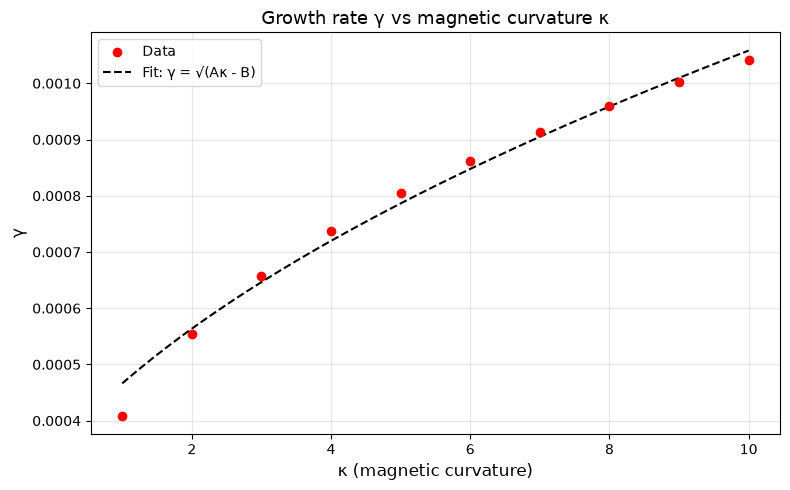

A = 0.0000, B = -0.0000


In [24]:
from scipy.optimize import curve_fit

def model(k, A, B, C):
    return A * np.sqrt(B * k - C)

# gamma² = A²(Bk - C) is linear in k, so fit gamma² first
coeffs = np.polyfit(k_values, np.asarray(gamma_values)**2, 1)
A0 = 1.0
B0 = coeffs[0] / A0**2
C0 = -coeffs[1] / A0**2

k_fit = np.linspace(min(k_values), max(k_values), 300)
gamma_fit = model(k_fit, A0, B0, C0)

plt.figure(figsize=(8, 5))
plt.scatter(k_values, gamma_values, color='red', zorder=5, label='Data')
plt.plot(k_fit, gamma_fit, color='black', linestyle='--', label=f'Fit: γ = √(Aκ - B)')
plt.xlabel('κ (magnetic curvature)', fontsize=12)
plt.ylabel('γ', fontsize=12)
plt.title('Growth rate γ vs magnetic curvature κ', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"A = {B0:.4f}, B = {C0:.4f}")

# Testing phi_0 scaling

In [35]:
import numpy as np
from scipy.linalg import eig

phi_0_values = np.arange(0,100,2)
gamma_values = np.zeros(50)

R = 0.002
N = 50    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 0.099
m = 1

k = np.ones(N)

# Equilibrium pressure and potential
L_p = 2
L_phi = 2
p_0  = np.exp(-r_values/L_phi)

print(r_values)

for i in range(50):
    phi_0 = phi_0_values[i]
    print(phi_0)

    phi_0 = phi_0 * np.exp(-r_values/L_p)

    # Initalizing matrices
    D1 = create_first_derivative_matrix(N, dr)
    D2 = create_second_derivative_matrix(N, dr)
    D3 = create_third_derivative_matrix(N, dr)
    Dm = create_m_laplacian(N, dr, m, r_values)

    diag_r = np.diag(r_values)
    diag_div_r = np.diag(1 / r_values)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values ** 2)) @ D1) @ phi_0)

    # Defining opereators
    L11 = (-1j * m * omega_0_diag @ Dm 
        + 1j * m * diag_div_r @ D_phi_prime_diag)

    L12 = - 2j * m * np.diag(k)
    L21 = 1j * m * np.diag(1 / r_values) @ np.diag(D1 @ p_0)
    L22 = - (1j * m * omega_0_diag)

    A = np.block([
    [Dm, np.zeros((N,N))],
    [np.zeros((N,N)), np.eye(N)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N, dr)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]

    gamma_values[i] = np.max(np.real(finite_evals))

[0.09904 0.09908 0.09912 0.09916 0.0992  0.09924 0.09928 0.09932 0.09936
 0.0994  0.09944 0.09948 0.09952 0.09956 0.0996  0.09964 0.09968 0.09972
 0.09976 0.0998  0.09984 0.09988 0.09992 0.09996 0.1     0.10004 0.10008
 0.10012 0.10016 0.1002  0.10024 0.10028 0.10032 0.10036 0.1004  0.10044
 0.10048 0.10052 0.10056 0.1006  0.10064 0.10068 0.10072 0.10076 0.1008
 0.10084 0.10088 0.10092 0.10096 0.101  ]
0
2
4
6
8
10
12
14
16
18
20
22
24
26
28
30
32
34
36
38
40
42
44
46
48
50
52
54
56
58
60
62
64
66
68
70
72
74
76
78
80
82
84
86
88
90
92
94
96
98


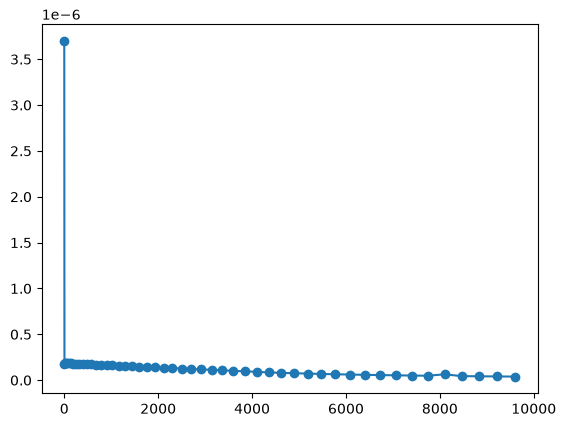

In [37]:
plt.plot(np.asarray(phi_0_values)**2, np.asarray(gamma_values)**2, 'o-')
# plt.yscale('log')
# plt.xscale('log')

slope = -0.0000, intercept = 0.0000


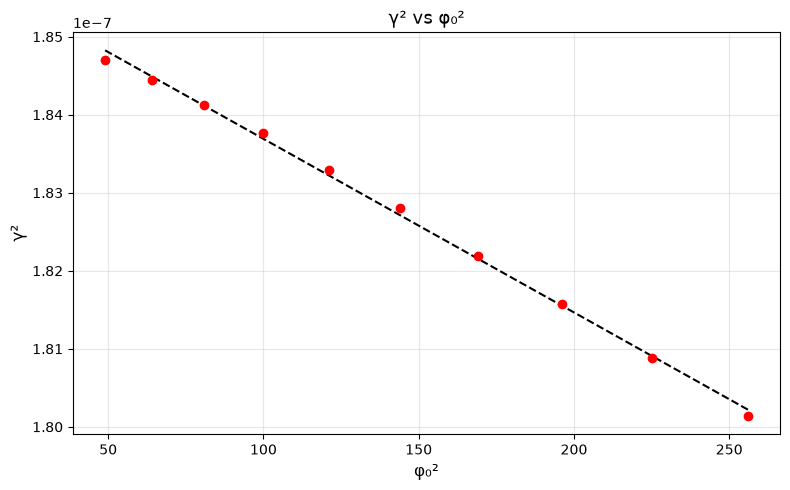

In [14]:
import matplotlib.pyplot as plt

phi0_sq = np.asarray(phi_0_values)**2
gamma_sq = np.asarray(gamma_values)**2

coeffs = np.polyfit(phi0_sq, gamma_sq, 1)
print(f"slope = {coeffs[0]:.4f}, intercept = {coeffs[1]:.4f}")
# expect: slope < 0, intercept = const term from pressure/curvature

phi0_sq_fit = np.linspace(min(phi0_sq), max(phi0_sq), 300)
gamma_sq_fit = np.polyval(coeffs, phi0_sq_fit)

plt.figure(figsize=(8, 5))
plt.scatter(phi0_sq, gamma_sq, color='red', zorder=5)
plt.plot(phi0_sq_fit, gamma_sq_fit, color='black', linestyle='--')
plt.xlabel('φ₀²', fontsize=12)
plt.ylabel('γ²', fontsize=12)
plt.title('γ² vs φ₀²', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()